# Import libraries

In [1]:
# Видаляємо потенційно конфліктні пакети
!pip uninstall -y transformers datasets accelerate evaluate torch torchvision torchaudio

# Встановлюємо сумісні версії
!pip install -q \
torch==2.7.1 \
torchvision==0.22.1 \
torchaudio==2.7.1 \
transformers==4.52.4 \
datasets==3.6.0 \
accelerate==1.7.0 \
evaluate==0.4.3 \
safetensors==0.5.3 \
sentencepiece==0.2.0

Found existing installation: transformers 5.13.1
Uninstalling transformers-5.13.1:
  Successfully uninstalled transformers-5.13.1
Found existing installation: datasets 4.0.0
Uninstalling datasets-4.0.0:
  Successfully uninstalled datasets-4.0.0
Found existing installation: accelerate 1.14.0
Uninstalling accelerate-1.14.0:
  Successfully uninstalled accelerate-1.14.0
Found existing installation: torch 2.11.0+cu128
Uninstalling torch-2.11.0+cu128:
  Successfully uninstalled torch-2.11.0+cu128
Found existing installation: torchvision 0.26.0+cu128
Uninstalling torchvision-0.26.0+cu128:
  Successfully uninstalled torchvision-0.26.0+cu128
Found existing installation: torchaudio 2.11.0+cu128
Uninstalling torchaudio-2.11.0+cu128:
  Successfully uninstalled torchaudio-2.11.0+cu128
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 821.0/821.0 MB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 120.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 118.

In [2]:
import torch
import torchvision
import torchaudio
import transformers
import datasets
import accelerate

print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)
print("torchaudio:", torchaudio.__version__)
print("transformers:", transformers.__version__)
print("datasets:", datasets.__version__)
print("accelerate:", accelerate.__version__)

torch: 2.7.1+cu126
torchvision: 0.22.1+cu126
torchaudio: 2.7.1+cu126
transformers: 4.52.4
datasets: 3.6.0
accelerate: 1.7.0


In [3]:
import json
import time

import joblib
import numpy as np
import pandas as pd
import torch
import accelerate

from datasets import Dataset
from scipy.special import softmax
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, DataCollatorWithPadding
from pathlib import Path
from model_utils import classify_analysis_bert, error_analysis_bert, compute_metrics

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
RANDOM_STATE = 42

PROCESS_DATA_PATH = "/content/drive/MyDrive/ML_course/Final_Project/preprocess_data"
MODEL_PATH = "/content/drive/MyDrive/ML_course/Final_Project/models/roberta"

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"Using device: {DEVICE}")

Using device: cuda


# Data Loading

In [6]:
train_df = pd.read_parquet(f"{PROCESS_DATA_PATH}/train_df_roberta.parquet")
val_df = pd.read_parquet(f"{PROCESS_DATA_PATH}/val_df_roberta.parquet")

In [7]:
with open(f"{PROCESS_DATA_PATH}/roberta_config.json", "r",) as f:
    config = json.load(f)

MODEL_CHECKPOINT = config["model_checkpoint"]
MAX_LENGTH = config["max_length"]

print(config)

{'model_checkpoint': 'FacebookAI/roberta-base', 'max_length': 80}


# Tokenizer

In [8]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

# Create Datasets

In [9]:
def tokenize_function(examples):

    return tokenizer(
        examples["question1_clean"],
        examples["question2_clean"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH,
    )

In [10]:
train_dataset = Dataset.from_pandas(train_df[["question1_clean", "question2_clean", "is_duplicate"]])
val_dataset = Dataset.from_pandas(val_df[["question1_clean", "question2_clean", "is_duplicate"]])

In [11]:
train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/261296 [00:00<?, ? examples/s]

Map:   0%|          | 0/62133 [00:00<?, ? examples/s]

In [12]:
train_dataset = train_dataset.rename_column("is_duplicate", "labels")
val_dataset = val_dataset.rename_column("is_duplicate", "labels")

In [13]:
train_dataset = train_dataset.remove_columns(["question1_clean", "question2_clean"])
val_dataset = val_dataset.remove_columns(["question1_clean", "question2_clean"])

In [14]:
train_dataset.set_format(type="torch")
val_dataset.set_format(type="torch")

In [15]:
print(train_dataset)
print(train_dataset[0])

Dataset({
    features: ['labels', 'input_ids', 'attention_mask'],
    num_rows: 261296
})
{'labels': tensor(0), 'input_ids': tensor([   0, 2264,   16, 7708, 1052,    8,   99,   16, 3461, 1052,  116,    2,
           2, 2264,   32,    5, 7708, 5894,    9, 3461, 1052,  116,    2,    1,
           1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
           1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
           1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
           1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
           1,    1,    1,    1,    1,    1,    1,    1]), 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0])}


# Model

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_CHECKPOINT,
    num_labels=2,
)

model.to(DEVICE)

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at FacebookAI/roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
         

In [ ]:
training_args = TrainingArguments(
    output_dir="/content/drive/MyDrive/ML_course/Final_Project/roberta_results",

    do_train=True,
    do_eval=True,

    num_train_epochs=3,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    learning_rate=2e-5,
    weight_decay=0.01,

    warmup_ratio=0.06,

    optim="adamw_torch",

    eval_strategy="steps",
    eval_steps=1000,

    save_strategy="steps",
    save_steps=1000,
    save_total_limit=2,

    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

    logging_strategy="steps",
    logging_steps=100,

    report_to="none",

    seed=RANDOM_STATE,
    fp16=torch.cuda.is_available()
)

In [ ]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

In [ ]:
start_time = time.perf_counter()
trainer.train()
training_time = time.perf_counter() - start_time
print(f"\nTraining time: {training_time:.2f} seconds")

Step,Training Loss,Validation Loss,Log Loss,F1,Runtime,Samples Per Second,Steps Per Second
1000,0.423400,0.405524,0.405523,0.751338,77.476800,801.956000,50.131000
2000,0.362400,0.392044,0.392044,0.749470,78.851200,787.978000,49.257000
3000,0.350600,0.368889,0.368889,0.778907,79.229400,784.216000,49.022000
4000,0.366400,0.368311,0.368311,0.788959,79.055200,785.944000,49.130000
5000,0.322300,0.390078,0.390079,0.787268,78.891200,787.578000,49.232000
6000,0.327300,0.383037,0.383038,0.777793,79.354400,782.981000,48.945000
7000,0.327300,0.384851,0.384849,0.790275,79.350700,783.017000,48.947000
8000,0.303200,0.382059,0.382059,0.762114,78.901400,787.477000,49.226000
9000,0.321400,0.347181,0.347182,0.799577,79.173400,784.772000,49.057000
10000,0.306800,0.388308,0.388307,0.790374,82.056600,757.197000,47.333000



Training time: 10104.43 seconds


In [ ]:
trainer.evaluate()

{'eval_loss': 0.4997187554836273,
 'eval_log_loss': 0.4997211187056344,
 'eval_f1': 0.8166425208257878,
 'eval_runtime': 77.0447,
 'eval_samples_per_second': 806.454,
 'eval_steps_per_second': 50.412,
 'epoch': 3.0}

In [ ]:
Path(MODEL_PATH).mkdir(parents=True, exist_ok=True)

trainer.save_model(MODEL_PATH)
tokenizer.save_pretrained(MODEL_PATH)

print(f"Model saved to: {MODEL_PATH}")

Model saved to: /content/drive/MyDrive/ML_course/Final_Project/models/roberta


# Evaluation

In [24]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)

In [25]:
model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)

In [26]:
trainer = Trainer(model=model)

Training
Log Loss      : 0.1616
ROC-AUC       : 0.9881
F1-score      : 0.9381
Inference time: 1329.7823 s


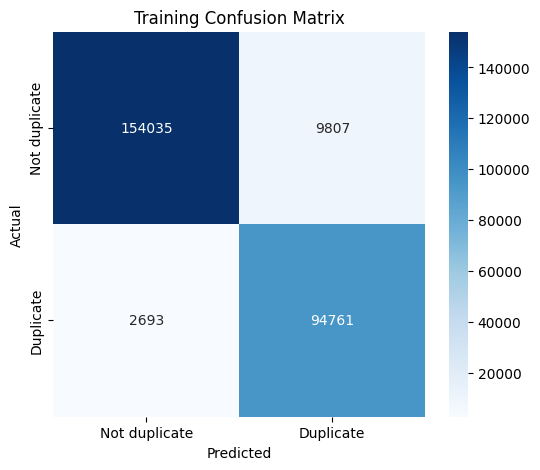


Classification Report:

              precision    recall  f1-score   support

           0     0.9828    0.9401    0.9610    163842
           1     0.9062    0.9724    0.9381     97454

    accuracy                         0.9522    261296
   macro avg     0.9445    0.9563    0.9496    261296
weighted avg     0.9542    0.9522    0.9525    261296



In [30]:
train_bert_results = classify_analysis_bert(trainer, train_dataset, 'Training')

Validation
Log Loss      : 0.4997
ROC-AUC       : 0.9374
F1-score      : 0.8167
Inference time: 318.0932 s


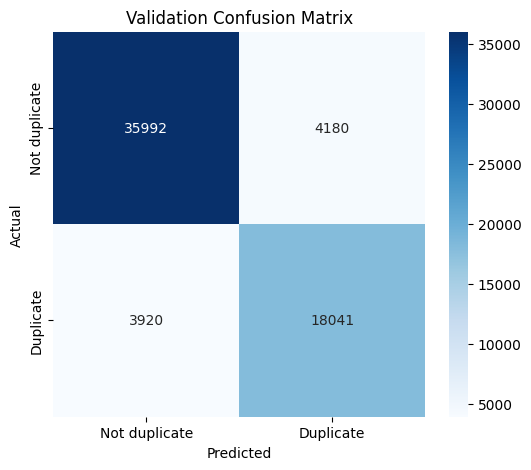


Classification Report:

              precision    recall  f1-score   support

           0     0.9018    0.8959    0.8989     40172
           1     0.8119    0.8215    0.8167     21961

    accuracy                         0.8696     62133
   macro avg     0.8568    0.8587    0.8578     62133
weighted avg     0.8700    0.8696    0.8698     62133



In [28]:
val_bert_results = classify_analysis_bert(trainer, val_dataset, 'Validation')

# Error analysis

In [31]:
train_bert_errors = error_analysis_bert(train_df, train_bert_results)
train_bert_errors["results"]

Error Analysis

TP : 94761
TN : 154035
FP : 9807
FN : 2693


,qid1,qid2,question1,question2,is_duplicate,split,question1_clean,question2_clean,prediction,probability
0,297402,297403,What is practical management and what is strat...,What are the practical aspects of strategic ma...,0,train,What is practical management and what is strat...,What are the practical aspects of strategic ma...,1,0.700674
1,184949,184950,How useful is MakeUseOf Answers?,Is there any Q&A site that is not Yahoo answer...,0,train,How useful is MakeUseOf Answers?,Is there any Q&A site that is not Yahoo answer...,0,0.000678
2,101283,163744,Which is the best place to reside in India and...,Which ia the best place to visit in India?,0,train,Which is the best place to reside in India and...,Which ia the best place to visit in India?,0,0.001344
3,17811,27517,Why do so many people ask questions on Quora t...,Why don't many people posting questions on Quo...,1,train,Why do so many people ask questions on Quora t...,Why don't many people posting questions on Quo...,1,0.996219
4,363829,363830,I got a seat in engineering management in Kett...,I am a petroleum engineer. Got an offer from S...,0,train,I got a seat in engineering management in Kett...,I am a petroleum engineer. Got an offer from S...,0,0.000638
...,...,...,...,...,...,...,...,...,...,...
261291,195424,7058,What changes a female body undergoes after loo...,What might be the reasons why people sometimes...,1,train,What changes a female body undergoes after loo...,What might be the reasons why people sometimes...,1,0.975506
261292,29426,29427,How do I move past my fear and learn options?,How do you move past fear?,0,train,How do I move past my fear and learn options?,How do you move past fear?,0,0.020448
261293,152504,152505,What are some of the best and most creative pr...,Which is one of the worst and most insensible ...,0,train,What are some of the best and most creative pr...,Which is one of the worst and most insensible ...,0,0.005452
261294,54414,54415,What are the tips given to a teacher to satisf...,Can a high school teacher legally force studen...,0,train,What are the tips given to a teacher to satisf...,Can a high school teacher legally force studen...,0,0.000650


In [ ]:
val_bert_errors = error_analysis_bert(val_df, val_bert_results)
val_bert_errors["results"]

Error Analysis

TP : 16370
TN : 36457
FP : 3715
FN : 5591


,qid1,qid2,question1,question2,is_duplicate,split,question1_clean,question2_clean,prediction,probability
0,459256,459257,The Iliad and the Odyssey in the Greek culture?,How do I prove that the pairs of three indepen...,0,val,The Iliad and the Odyssey in the Greek culture?,How do I prove that the pairs of three indepen...,0,0.000019
1,70709,109144,How can I open a PPF account? And what are its...,What is PPF account?,1,val,How can I open a PPF account? And what are its...,What is PPF account?,0,0.115386
2,6421,68425,"What is the Sahara, and how do the average tem...","What is the Sahara, and how do the average tem...",1,val,"What is the Sahara, and how do the average tem...","What is the Sahara, and how do the average tem...",0,0.015107
3,26893,83712,When is it too late to learn piano?,Is it too late to learn to play the piano at 26?,1,val,When is it too late to learn piano?,Is it too late to learn to play the piano at 26?,0,0.001438
4,353543,353544,Can XY chromosomes change to XX ones?,What are XX and XY chromosomes? How are they d...,0,val,Can XY chromosomes change to XX ones?,What are XX and XY chromosomes? How are they d...,0,0.014794
...,...,...,...,...,...,...,...,...,...,...
62128,87381,87382,What is adaptive expectation?,What is adaptability?,0,val,What is adaptive expectation?,What is adaptability?,0,0.000181
62129,6270,343259,What is the solution to this puzzle?,What is the solution to these puzzles?,0,val,What is the solution to this puzzle?,What is the solution to these puzzles?,0,0.000432
62130,89946,89947,What types of questions are asked in front-end...,What interview questions should I ask a front ...,0,val,What types of questions are asked in front-end...,What interview questions should I ask a front ...,0,0.006015
62131,182893,182894,What are the major stereotypes people have abo...,What are the major stereotypes people have abo...,0,val,What are the major stereotypes people have abo...,What are the major stereotypes people have abo...,0,0.000037


In [ ]:
train_best_bert_errors = error_analysis_bert(train_df, train_best_bert_results)
train_best_bert_errors["results"]

Error Analysis

TP : 90361
TN : 147123
FP : 16719
FN : 7093


,qid1,qid2,question1,question2,is_duplicate,split,question1_clean,question2_clean,prediction,probability
0,297402,297403,What is practical management and what is strat...,What are the practical aspects of strategic ma...,0,train,What is practical management and what is strat...,What are the practical aspects of strategic ma...,1,0.786439
1,184949,184950,How useful is MakeUseOf Answers?,Is there any Q&A site that is not Yahoo answer...,0,train,How useful is MakeUseOf Answers?,Is there any Q&A site that is not Yahoo answer...,0,0.000279
2,101283,163744,Which is the best place to reside in India and...,Which ia the best place to visit in India?,0,train,Which is the best place to reside in India and...,Which ia the best place to visit in India?,1,0.877436
3,17811,27517,Why do so many people ask questions on Quora t...,Why don't many people posting questions on Quo...,1,train,Why do so many people ask questions on Quora t...,Why don't many people posting questions on Quo...,1,0.984698
4,363829,363830,I got a seat in engineering management in Kett...,I am a petroleum engineer. Got an offer from S...,0,train,I got a seat in engineering management in Kett...,I am a petroleum engineer. Got an offer from S...,0,0.000242
...,...,...,...,...,...,...,...,...,...,...
261291,195424,7058,What changes a female body undergoes after loo...,What might be the reasons why people sometimes...,1,train,What changes a female body undergoes after loo...,What might be the reasons why people sometimes...,1,0.929227
261292,29426,29427,How do I move past my fear and learn options?,How do you move past fear?,0,train,How do I move past my fear and learn options?,How do you move past fear?,1,0.659151
261293,152504,152505,What are some of the best and most creative pr...,Which is one of the worst and most insensible ...,0,train,What are some of the best and most creative pr...,Which is one of the worst and most insensible ...,0,0.074221
261294,54414,54415,What are the tips given to a teacher to satisf...,Can a high school teacher legally force studen...,0,train,What are the tips given to a teacher to satisf...,Can a high school teacher legally force studen...,0,0.000824


In [29]:
val_best_bert_errors = error_analysis_bert(val_df, val_bert_results)
val_best_bert_errors["results"]

Error Analysis

TP : 18041
TN : 35992
FP : 4180
FN : 3920


,qid1,qid2,question1,question2,is_duplicate,split,question1_clean,question2_clean,prediction,probability
0,459256,459257,The Iliad and the Odyssey in the Greek culture?,How do I prove that the pairs of three indepen...,0,val,The Iliad and the Odyssey in the Greek culture?,How do I prove that the pairs of three indepen...,0,0.000650
1,70709,109144,How can I open a PPF account? And what are its...,What is PPF account?,1,val,How can I open a PPF account? And what are its...,What is PPF account?,0,0.096447
2,6421,68425,"What is the Sahara, and how do the average tem...","What is the Sahara, and how do the average tem...",1,val,"What is the Sahara, and how do the average tem...","What is the Sahara, and how do the average tem...",0,0.000897
3,26893,83712,When is it too late to learn piano?,Is it too late to learn to play the piano at 26?,1,val,When is it too late to learn piano?,Is it too late to learn to play the piano at 26?,0,0.032182
4,353543,353544,Can XY chromosomes change to XX ones?,What are XX and XY chromosomes? How are they d...,0,val,Can XY chromosomes change to XX ones?,What are XX and XY chromosomes? How are they d...,0,0.015893
...,...,...,...,...,...,...,...,...,...,...
62128,87381,87382,What is adaptive expectation?,What is adaptability?,0,val,What is adaptive expectation?,What is adaptability?,0,0.000817
62129,6270,343259,What is the solution to this puzzle?,What is the solution to these puzzles?,0,val,What is the solution to this puzzle?,What is the solution to these puzzles?,0,0.001042
62130,89946,89947,What types of questions are asked in front-end...,What interview questions should I ask a front ...,0,val,What types of questions are asked in front-end...,What interview questions should I ask a front ...,0,0.001349
62131,182893,182894,What are the major stereotypes people have abo...,What are the major stereotypes people have abo...,0,val,What are the major stereotypes people have abo...,What are the major stereotypes people have abo...,0,0.000648


**Observation:**
- RoBERTa achieves the best F1 (~0.82) and ROC-AUC (~0.94) in the entire project, but a worse Log Loss (~0.50) than tuned XGBoost on sentence embeddings (~0.33) — a direct effect of selecting the best checkpoint by F1 (`metric_for_best_model="f1"`) rather than by Log Loss, the project's primary evaluation metric.
- Training (~2h) and inference (~318s) costs rule this model out for the 
  production API despite its quality edge.

# Next steps

- If Log Loss is the metric that matters, re-run with `metric_for_best_model="eval_loss"` to see whether checkpoint selection alone closes the gap to XGBoost.